##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, CenterCrop, Resize, Compose

import os.path
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import scalarConditionedNetworkCNN, scalarConditionedNetworkUNet, timeConditionedField
from svipy.normflow import identityTimeEmbedding, fourierTimeEmbedding, filmTimeEmbedding
from svipy.diffusion import linearConditionalPath, conditionalScoreMatcher, diffusionSampler
from svipy.diffusion import varPreservingConditionalPathTrigonometric, varPreservingConditionalPathDDPMCosine
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class celebaTensorDataset(torch.utils.data.Dataset):
    def __init__(self, images):
        self.images = images # torch.load(path)   # uint8, (N, 3, 64, 64)

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, index):
        return self.images[index].float() / 127.5 - 1.0   # uint8[0,255] -> float32[-1,1]

In [3]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return 2.0 * self.original[index][self.index] - 1.

In [4]:
def convert(root: str, split: str, batchSize=64, imageSize=64):
    # CenterCrop(178) before resizing: CelebA's "aligned" images aren't square
    # (218 tall x 178 wide), and the extra height is background/hair, not face
    # Cropping to the square 178 x 178 center before downsizing is standard
    # preprocessing for this dataset.
    transform = Compose([CenterCrop(178),
                         Resize(imageSize),
                         ToTensor(),   # -> float32 in [0,1], shape (3, H, W)
                        ])
    
    dataset = datasets.CelebA(root=root, split=split, transform=transform, download=True, target_type='attr')
    outPath = f"{root}/celeba/celeba_{split}_{imageSize}.pt"

    if os.path.isfile(outPath):
        print(f"{outPath} already exists")
        images = torch.load(outPath, weights_only=False)
        return dataset, celebaTensorDataset(images)
    
    loader = DataLoader(dataset, batch_size=batchSize)
    n = len(dataset)

    # store as uint8 (0-255), not float - ~4x smaller on disk/in memory, and
    # pixel data has no precision to lose; convert to float and normalize
    # when loading for training
    images = torch.empty(n, 3, imageSize, imageSize, dtype=torch.uint8)
    idx = 0
    for batch, _ in loader: # we don't need labels, just discard them
        b = batch.shape[0]
        images[idx:idx + b] = (batch * 255).round().to(torch.uint8)
        idx += b
        print(f"{split}: {idx}/{n}", end="\r")

    
    torch.save(images, outPath)
    print(f"\nsaved {tuple(images.shape)} ({images.element_size() * images.nelement() / 1e9:.2f} GB) to {outPath}")
    
    return dataset, celebaTensorDataset(images)

In [5]:
trainData, trainTensorData = convert("../data", 'train', 64, 64)
testData, testTensorData = convert("../data", 'test', 64, 64)
validData, validTensorData = convert("../data", 'valid', 64, 64)

print(len(trainData), len(testData), len(validData), len(trainTensorData), len(testTensorData), len(validTensorData))

Files already downloaded and verified
../data/celeba/celeba_train_64.pt already exists
Files already downloaded and verified
../data/celeba/celeba_test_64.pt already exists
Files already downloaded and verified
../data/celeba/celeba_valid_64.pt already exists
162770 19962 19867 162770 19962 19867


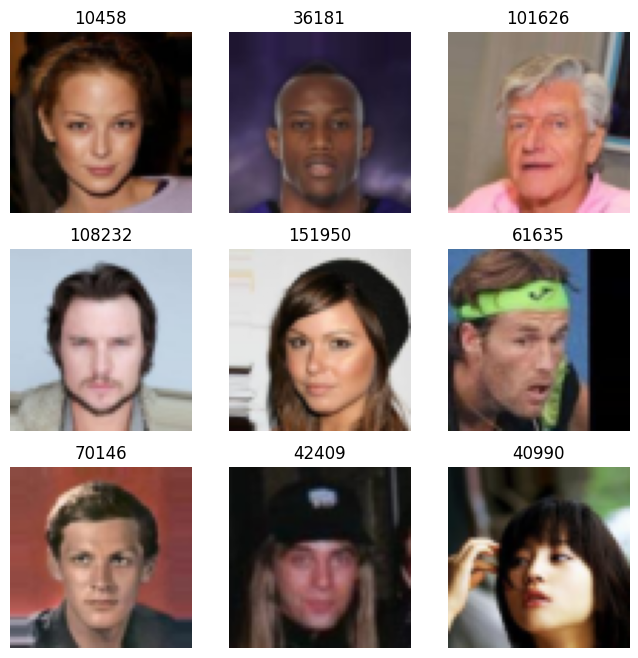

In [6]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(sidx))
    plt.axis("off")
    plt.imshow(img.permute([1, 2, 0]))
plt.show()

###### Hardware Specs

In [7]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### Conditional Flow Matching

###### Trigonometric Var preserving paths

In [8]:
tcn = scalarConditionedNetworkUNet(3, [32, 64, 128, 256], t_dim=0) 
embed = filmTimeEmbedding(tcn.filmDims())
tcf = timeConditionedField(tcn, embed)

path = varPreservingConditionalPathDDPMCosine(target='score')

model_diff_ddpm = conditionalScoreMatcher(path, tcf).to(device)

In [9]:
learning_rate = 0.001
batch_size = 32
epochs = 200

trainLoader = DataLoader(trainTensorData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(validTensorData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_diff_ddpm.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=10, minDelta=0.1, mode='min', restoreBestWeights=True)

In [ ]:
%%time 
model_diff_ddpm.trainLoop(trainLoader, optimizer, epochs, 
                          reportIters=100, scheduler=None,
                          checkpointPath='../checkpoints/celeba_diff/',
                          checkPointName='diff_trig',
                          validDataLoader=validLoader,
                          earlyStopper=stopper
                         )

Epoch 1
-------------------------------
totalLoss: 5131.216797[ 3200/162770]
totalLoss: 3195.722656[ 6400/162770]
totalLoss: 4213.345703[ 9600/162770]
totalLoss: 1731.911499[12800/162770]
totalLoss: 1617.016113[16000/162770]
totalLoss: 1747.699463[19200/162770]
totalLoss: 1518.748047[22400/162770]
totalLoss: 2198.301758[25600/162770]
totalLoss: 2292.661621[28800/162770]
totalLoss: 2039.476318[32000/162770]
totalLoss: 1628.626709[35200/162770]
totalLoss: 1713.664307[38400/162770]
totalLoss: 1187412836352.000000[41600/162770]
totalLoss: 4545226752.000000[44800/162770]
totalLoss: 2868916992.000000[48000/162770]
totalLoss: 1189133440.000000[51200/162770]
totalLoss: 666599552.000000[54400/162770]
totalLoss: 19941683200.000000[57600/162770]
totalLoss: 13446184960.000000[60800/162770]
totalLoss: 7045663744.000000[64000/162770]
totalLoss: 5520600064.000000[67200/162770]
totalLoss: 2413404928.000000[70400/162770]
totalLoss: 4275663872.000000[73600/162770]
totalLoss: 1698776192.000000[76800/1627

In [36]:
model_diff_ddpm.load_state_dict(torch.load('../checkpoints/celeba_diff/diff_trig-8.model', weights_only=True)['model_state_dict'])

<All keys matched successfully>

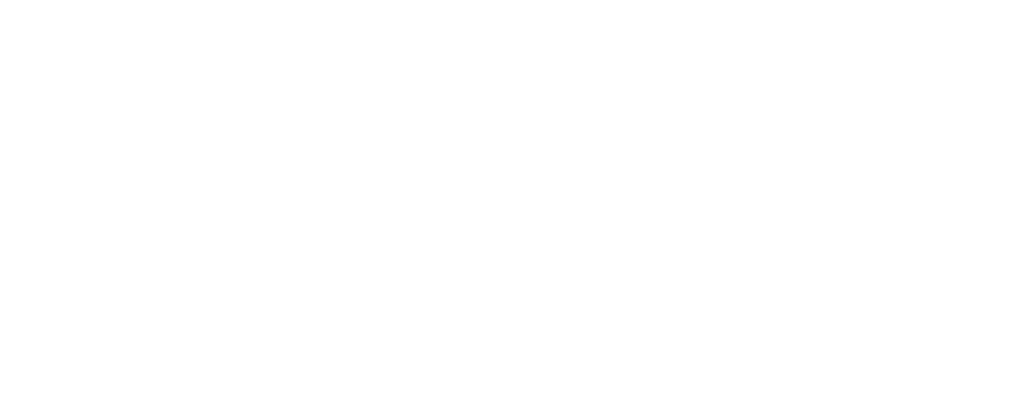

In [34]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = diffusionSampler(tcf, path)

idxs = []

with torch.no_grad():
    for i in range(2 * nRows):
        x0 = torch.randn([1, 3, 32, 32]).to(device)

        for j, l in enumerate([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
            img = cnf.interpolate(x0, 0., 1., l, 1000)[0].cpu().detach()
            img = (torch.clamp(img, -1.,  1.) + 1.) / 2.
            img = img.numpy()
        
            figure.add_subplot(nRows, nCols, 6 * i + j + 1)
            plt.axis("off")
            plt.imshow(img.transpose([1, 2, 0]))

plt.show()

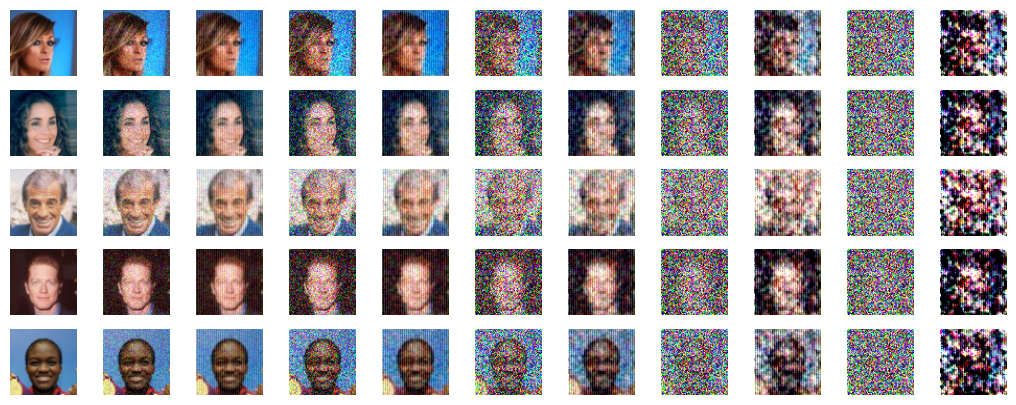

In [35]:
nCols = 11
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = diffusionSampler(tcf, path).to(device)

idxs = []
tx = [0.1, 0.25, 0.5, 0.75, 0.9]

sidx = torch.randint(len(trainData), size=(1,)).item()
x1 = trainImageData[sidx]
x0 = torch.randn_like(x1).unsqueeze(0).to(device)  # sample a single noise image

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, _ = trainData[sidx]
        x1 = trainImageData[sidx]
        x1 = x1.unsqueeze(0)

        # original image
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.permute([1, 2, 0]))

        x1 = x1.to(device)        
        for j, txj in enumerate(tx):
            # interpolated
            xt, _ = path(x0, x1, torch.tensor([txj]).to(device))
            img = (torch.clamp(xt, -1., 1.) + 1.) / 2.
            img = img.squeeze().cpu().detach().numpy()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 2)
            plt.axis("off")
            plt.imshow(img.transpose([1, 2, 0]))

            # generated
            img = cnf.interpolate(xt, 0., txj, 0., 200)[0].squeeze().cpu().detach()
            img = torch.clamp(img, -1., 1.)
            img = (img.numpy() + 1.) / 2.
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 3)
            plt.axis("off")
            plt.imshow(img.transpose([1, 2, 0]))

plt.show()